In [98]:
import numpy as np 
import pandas as pd
from scipy import ndimage 
from scipy.cluster import hierarchy 
from scipy.spatial import distance_matrix 
from matplotlib import pyplot as plt 
from sklearn import manifold, datasets 
from sklearn.cluster import AgglomerativeClustering 
from sklearn.datasets import make_blobs 
from sklearn.preprocessing import MinMaxScaler

In [99]:
# importing data
!wget -O cars_clus.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%204/data/cars_clus.csv

--2026-01-31 02:00:23--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%204/data/cars_clus.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17774 (17K) [text/csv]
Saving to: ‘cars_clus.csv’

cars_clus.csv       100%[===================>]  17.36K  --.-KB/s    in 0.001s  

2026-01-31 02:00:25 (25.2 MB/s) - ‘cars_clus.csv’ saved [17774/17774]



In [100]:
file_name = 'cars_clus.csv'

df = pd.read_csv(file_name)
print(df.dtypes)
df.head()

manufact         str
model            str
sales            str
resale           str
type             str
price            str
engine_s         str
horsepow         str
wheelbas         str
width            str
length           str
curb_wgt         str
fuel_cap         str
mpg              str
lnsales          str
partition    float64
dtype: object


,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition
0,Acura,Integra,16.919,16.360,0.000,21.500,1.800,140.000,101.200,67.300,172.400,2.639,13.200,28.000,2.828,0.0
1,Acura,TL,39.384,19.875,0.000,28.400,3.200,225.000,108.100,70.300,192.900,3.517,17.200,25.000,3.673,0.0
2,Acura,CL,14.114,18.225,0.000,$null$,3.200,225.000,106.900,70.600,192.000,3.470,17.200,26.000,2.647,0.0
3,Acura,RL,8.588,29.725,0.000,42.000,3.500,210.000,114.600,71.400,196.600,3.850,18.000,22.000,2.150,0.0
4,Audi,A4,20.397,22.255,0.000,23.990,1.800,150.000,102.600,68.200,178.000,2.998,16.400,27.000,3.015,0.0


In [101]:
# cleaning data

columns = ['sales', 'resale', 'type', 'price', 'engine_s', 'horsepow', 'wheelbas', 'width', 'length', 'curb_wgt', 'fuel_cap', 'mpg', 'lnsales', 'partition']
df[columns] = df[columns].apply(pd.to_numeric, errors='coerce')
df = df.dropna(axis=0, how='any')
df = df.dropna(subset=columns)
df.dtypes

manufact         str
model            str
sales        float64
resale       float64
type         float64
price        float64
engine_s     float64
horsepow     float64
wheelbas     float64
width        float64
length       float64
curb_wgt     float64
fuel_cap     float64
mpg          float64
lnsales      float64
partition    float64
dtype: object

In [102]:
# normalizing data

df[columns] = MinMaxScaler().fit_transform(df[columns])
df.head()


,manufact,model,sales,resale,type,price,engine_s,horsepow,wheelbas,width,length,curb_wgt,fuel_cap,mpg,lnsales,partition
0,Acura,Integra,0.031102,0.179516,0.0,0.167178,0.114286,0.215190,0.186551,0.281437,0.306258,0.231056,0.133641,0.433333,0.592353,0.0
1,Acura,TL,0.072669,0.235855,0.0,0.261228,0.314286,0.430380,0.336226,0.461078,0.579228,0.503727,0.317972,0.333333,0.691765,0.0
3,Acura,RL,0.015687,0.393733,0.0,0.446603,0.357143,0.392405,0.477223,0.526946,0.628495,0.607143,0.354839,0.233333,0.512588,0.0
4,Audi,A4,0.037537,0.274002,0.0,0.201118,0.114286,0.240506,0.216920,0.335329,0.380826,0.342547,0.281106,0.400000,0.614353,0.0
5,Audi,A6,0.034545,0.294839,0.0,0.336877,0.257143,0.367089,0.349241,0.808383,0.567244,0.517391,0.377880,0.233333,0.604706,0.0


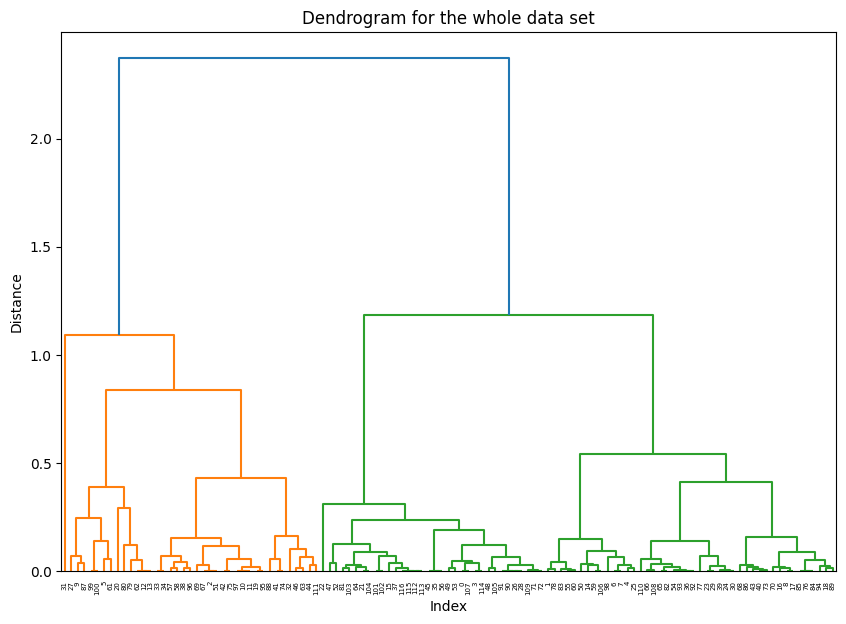

In [108]:
from scipy.cluster.hierarchy import dendrogram, fcluster

cluster1 = df[['engine_s', 'horsepow']].values

fig = plt.figure(figsize=(10, 7))
clst = hierarchy.linkage(cluster1, method='ward')
dendro = dendrogram(clst)
plt.title('Dendrogram for the whole data set')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.show()